# H2 — Insurance Claims Cost/Risk Predictive Model

**Data:** CMS DE-SynPUF Sample 1 (2008 Beneficiary Summary + 2008-2010 Inpatient Claims) — fully synthetic Medicare claims data, safe to use publicly with no PHI.

**Goal:** flag Medicare beneficiaries likely to become top-decile ("high-cost") inpatient claimants, using only information a payer would have *in advance* — prior-year utilization and demographics — so the model reflects a real prospective risk-scoring use case (e.g., who to enroll in a care-management program).

**Framing note:** features are built from **2008** claims/demographics only; the label (`high_cost`) is whether the beneficiary lands in the top 10% of **2009-2010** inpatient spend. This avoids the circular "this year's claim count predicts this year's spend" trap and mirrors how prospective risk models are actually used.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

ROOT = Path("..")
RAW = ROOT / "Data" / "raw"
PROCESSED = ROOT / "Data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

C:\Users\emily\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load

In [2]:
beneficiary = pd.read_csv(RAW / "DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv")
claims = pd.read_csv(RAW / "DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv")
print(f"Beneficiaries: {len(beneficiary):,}  |  Inpatient claim lines: {len(claims):,}")
beneficiary.head()

Beneficiaries: 116,352  |  Inpatient claim lines: 66,773


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR
0,00013D2EFD8E45D1,19230501,NaN,1,1,0,26,950,12,12,...,2,0.0,0.0,0.0,50.0,10.0,0.0,0.0,0.0,0.0
1,00016F745862898F,19430101,NaN,1,1,0,39,230,12,12,...,2,0.0,0.0,0.0,0.0,0.0,0.0,700.0,240.0,0.0
2,0001FDD721E223DC,19360901,NaN,2,1,0,39,280,12,12,...,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00021CA6FF03E670,19410601,NaN,1,5,0,6,290,0,0,...,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00024B3D2352D2D0,19360801,NaN,1,1,0,52,590,12,12,...,2,0.0,0.0,0.0,30.0,40.0,0.0,220.0,80.0,0.0


## Step 2 — Feature engineering (prospective split: 2008 features → 2009-2010 label)

In [3]:
# Age as of the start of the study window (2008-01-01), derived from BENE_BIRTH_DT (YYYYMMDD int)
birth_year = (beneficiary["BENE_BIRTH_DT"] // 10000).astype(int)
beneficiary["BENE_AGE"] = 2008 - birth_year

claims = claims.dropna(subset=["CLM_FROM_DT"])
claims["year"] = (claims["CLM_FROM_DT"] // 10000).astype(int)

prior = claims[claims["year"] <= 2008]
future = claims[claims["year"] >= 2009]

prior_agg = prior.groupby("DESYNPUF_ID").agg(
    prior_cost=("CLM_PMT_AMT", "sum"),
    num_claims=("CLM_ID", "count"),
).reset_index()

future_agg = future.groupby("DESYNPUF_ID").agg(
    future_cost=("CLM_PMT_AMT", "sum"),
).reset_index()

df = beneficiary.merge(prior_agg, on="DESYNPUF_ID", how="left")
df = df.merge(future_agg, on="DESYNPUF_ID", how="left")
df["num_claims"] = df["num_claims"].fillna(0)
df["prior_cost"] = df["prior_cost"].fillna(0)
df["future_cost"] = df["future_cost"].fillna(0)

threshold = df["future_cost"].quantile(0.90)
df["high_cost"] = (df["future_cost"] >= threshold).astype(int)

chronic_cols = [c for c in df.columns if c.startswith("SP_")]
df["num_chronic"] = df[chronic_cols].apply(lambda x: (x == 1).sum(), axis=1)
df["is_male"] = (df["BENE_SEX_IDENT_CD"] == 1).astype(int)
df["has_esrd"] = (df["BENE_ESRD_IND"] == "Y").astype(int)

print(f"High-cost threshold (90th pct of 2009-2010 inpatient cost): ${threshold:,.0f}")
print(f"High-cost claimants (2009-2010): {df['high_cost'].sum():,} ({df['high_cost'].mean():.1%})")

High-cost threshold (90th pct of 2009-2010 inpatient cost): $11,000
High-cost claimants (2009-2010): 12,285 (10.6%)


## Step 3 — Train/test split and model

In [4]:
features = ["BENE_AGE", "num_chronic", "num_claims", "prior_cost", "is_male", "has_esrd"]
X = df[features]
y = df["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, preds)
print("AUC:", round(auc, 4))
print(classification_report(y_test, (preds > 0.5).astype(int)))

AUC: 0.7253
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     20814
           1       0.50      0.00      0.00      2457

    accuracy                           0.89     23271
   macro avg       0.70      0.50      0.47     23271
weighted avg       0.85      0.89      0.84     23271



**Why AUC ~0.73, not ~0.95:** the label is genuinely hard to predict from prior-year info alone — only 10.6% of beneficiaries are high-cost, and future cost has real randomness (an acute event in 2009-2010 isn't fully knowable from 2008 data). A 0.5 probability cutoff is also the wrong lens for a rare-event label — see the top-decile evaluation below, which reflects how this would actually be used (rank and enroll the highest-risk slice into a program, not threshold at 50%).

In [5]:
test_eval = pd.DataFrame({"y_true": y_test.values, "score": preds}).sort_values("score", ascending=False)
top_decile_n = max(1, int(len(test_eval) * 0.10))
top_decile = test_eval.head(top_decile_n)
capture_rate = top_decile["y_true"].sum() / y_test.sum()
precision_at_decile = top_decile["y_true"].mean()

print(f"Flagging the top {top_decile_n} of {len(test_eval)} test members by predicted risk:")
print(f"  Precision@decile: {precision_at_decile:.1%} (vs. {y_test.mean():.1%} base rate) -> {precision_at_decile/y_test.mean():.1f}x lift")
print(f"  Capture rate: {capture_rate:.1%} of all actual high-cost members caught in that top 10%")

Flagging the top 2327 of 23271 test members by predicted risk:
  Precision@decile: 25.7% (vs. 10.6% base rate) -> 2.4x lift
  Capture rate: 24.3% of all actual high-cost members caught in that top 10%


## Step 4 — SHAP explainability

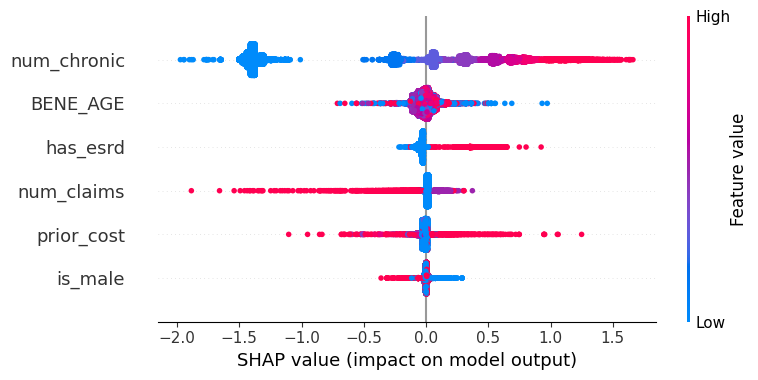

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig(ROOT / "shap_summary.png", bbox_inches="tight", dpi=150)
plt.show()

In [7]:
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=features).sort_values(ascending=False)
mean_abs_shap

num_chronic    0.812297
BENE_AGE       0.058590
has_esrd       0.057770
num_claims     0.031379
prior_cost     0.022846
is_male        0.010262
dtype: float32

**Reading the plot:** `num_chronic` (count of chronic conditions on file) dominates — more chronic conditions pushes predicted risk sharply higher, which lines up with clinical intuition and is the single most actionable lever for a care-management team (target multi-morbid members first). `has_esrd` (end-stage renal disease) is a strong secondary signal, consistent with dialysis being one of Medicare's most expensive chronic treatments.

## Step 5 — Save model + scored dataset

In [8]:
pickle.dump(model, open(ROOT / "model.pkl", "wb"))

df["predicted_risk"] = model.predict_proba(X)[:, 1]
df[["DESYNPUF_ID", "BENE_AGE", "num_chronic", "num_claims", "prior_cost", "is_male", "has_esrd",
    "future_cost", "high_cost", "predicted_risk"]].to_csv(PROCESSED / "claims_scored.csv", index=False)

print("Saved model.pkl and Data/processed/claims_scored.csv")

Saved model.pkl and Data/processed/claims_scored.csv
